# ProteinGym Offline Design Experiment Tutorial

This tutorial demonstrates how to run an offline active learning experiment using the
[ProteinGym](https://instadeepai.github.io/alf/api/alf_tools/datasets/proteingym/) dataset.
ProteinGym is a large-scale benchmark containing hundreds of Deep Mutational Scanning (DMS)
assays — each assay measures the fitness effect of thousands of protein variants relative to
a wild-type sequence.

No HuggingFace token is required. Data is downloaded automatically from the public
[`OATML-Markslab/ProteinGym_v1`](https://huggingface.co/datasets/OATML-Markslab/ProteinGym_v1)
dataset and cached locally on first use.

### Experiment Overview

We will:
1. Load the `IF1_ECOLI_Kelsic_2016` singles assay and explore its structure
2. Compare a standard random split against the ProteinGym cross-validation (modulo) split
3. Train a CNN surrogate model on the training set
4. Run an offline active learning loop over the candidate pool
5. Evaluate how efficiently the optimizer discovers high-fitness variants

### Framework Components

1. **Dataset** ([`ProteinGym`](https://instadeepai.github.io/alf/api/alf_tools/datasets/proteingym/)): Loads a DMS assay and splits it into train / validation / test / candidate-pool sets. Supports both random splits and ProteinGym's three cross-validation strategies (random, modulo, contiguous).

2. **Surrogate Model** ([`CNNModel`](https://instadeepai.github.io/alf/api/alf_tools/models/cnn/)): Trained on the labelled training set to predict DMS fitness scores for unseen variants.

3. **Search Strategy** ([`DatasetSearch`](https://instadeepai.github.io/alf/api/alf_core/optimizer/search/)): Draws candidates from the pre-defined candidate pool (the unlabelled portion of the assay).

4. **Acquisition Function** ([`Greedy`](https://instadeepai.github.io/alf/api/alf_core/optimizer/acquisition_function/)): Ranks candidates by predicted fitness and selects the top-scoring ones.

5. **Optimizer** ([`Optimizer`](https://instadeepai.github.io/alf/api/alf_core/optimizer/optimizer/)): Combines acquisition function + search strategy to implement the ask/tell loop.

6. **Oracle** ([`Oracle`](https://instadeepai.github.io/alf/api/alf_core/oracle/)): Simulates wet-lab evaluation by returning the true DMS score from the dataset.

7. **Task** ([`DesignTask`](https://instadeepai.github.io/alf/api/alf_core/tasks/design_task/)): Orchestrates multiple acquisition rounds and logs metrics.

### Step 0: Environment Setup

From the `/tutorials` directory run:

```bash
uv sync
source .venv/bin/activate
```

Then select `.venv` as the kernel when starting the notebook.

In [1]:
import subprocess
import sys

subprocess.check_call(["uv", "pip", "install", "-e", ".", "--python", sys.executable])

Resolved 88 packages in 704ms
   Building alf-tutorials @ file:///Users/s.surana/Desktop/alf/tutorials


      Built alf-tutorials @ file:///Users/s.surana/Desktop/alf/tutorials
Prepared 1 package in 510ms
Uninstalled 1 package in 1ms
Installed 1 package in 2ms
 ~ alf-tutorials==0.1.0 (from file:///Users/s.surana/Desktop/alf/tutorials)


0

### Step 1: Import Required Libraries

In [2]:
import shutil

import matplotlib.pyplot as plt
import pandas as pd
from alf_core import (
    DatasetSearch,
    DesignTask,
    FileStateLogger,
    Optimizer,
    Oracle,
    Surrogate,
    TerminalStateLogger,
)
from alf_tools.datasets import ProteinGym
from alf_tools.datasets.proteingym import ProteinGymConfig
from alf_tools.models import CNNModel
from alf_tools.optimizer.acquisition_functions import Greedy

print("✅ All imports successful!")

✅ All imports successful!


### Step 2: Load and Explore the ProteinGym Dataset

We use the `IF1_ECOLI_Kelsic_2016` assay — 1,367 single-point variants of the *E. coli*
IF1 protein with measured fitness scores.

On first run this downloads the relevant shard from
`OATML-Markslab/ProteinGym_v1` and caches it locally — no token needed.

In [3]:
from alf_core.dataclasses.candidate import Modality

dataset = ProteinGym(
    ProteinGymConfig(
        name="proteingym",
        modality=Modality.SEQUENCE,
        seed=42,
        dms_name="IF1_ECOLI_Kelsic_2016",
        dms_type="singles",
        train_ratio=0.6,
        validation_frac=0.1,
        test_ratio=0.2,
        split_type="random",
        problem_type="regression",
    )
)

print(f"Train set:       {len(dataset.train_dataset):>5} variants")
print(f"Validation set:  {len(dataset.validation_dataset):>5} variants")
print(f"Test set:        {len(dataset.test_dataset):>5} variants")
print(f"Candidate pool:  {len(dataset.candidate_pool):>5} variants")
print()
example = dataset.train_dataset.candidates[0]
print(f"Example sequence (first 40 aa): {example.data[:40]}")
print(f"Features:                       {list(example.features.keys())}")

Train set:         738 variants
Validation set:     82 variants
Test set:          273 variants
Candidate pool:    274 variants

Example sequence (first 40 aa): MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKM
Features:                       ['mutant_code', 'random_fold_id', 'modulo_fold_id', 'contiguous_fold_id']


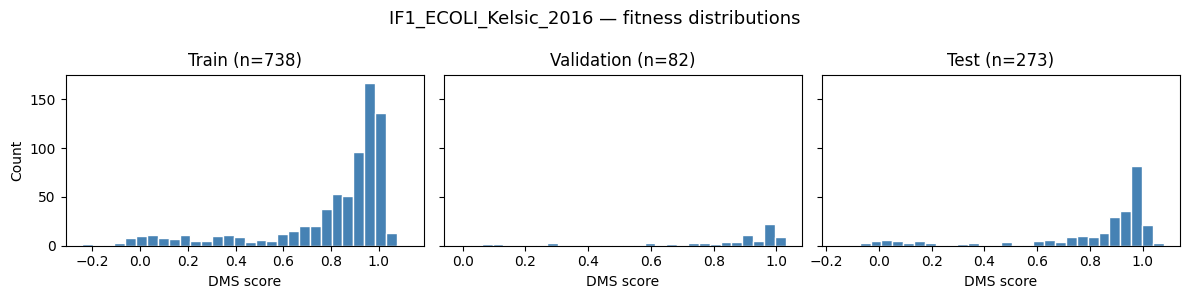

In [4]:
# Plot the fitness score distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
splits = [
    ("Train", dataset.train_dataset.labels),
    ("Validation", dataset.validation_dataset.labels),
    ("Test", dataset.test_dataset.labels),
]
for ax, (name, labels) in zip(axes, splits):
    ax.hist(labels, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{name} (n={len(labels)})")
    ax.set_xlabel("DMS score")
axes[0].set_ylabel("Count")
fig.suptitle("IF1_ECOLI_Kelsic_2016 — fitness distributions", fontsize=13)
plt.tight_layout()
plt.show()

### Step 3: ProteinGym Cross-Validation Splits

ProteinGym defines three cross-validation strategies for fair benchmarking:

| Strategy | How it works | Use case |
|---|---|---|
| `modulo` | fold = (residue_position − 1) % 5 | Interleaved position coverage |
| `contiguous` | fold = contiguous block of positions | Tests generalisation to unseen regions |
| `random` | random position-level shuffle (fixed seed) | Standard random holdout |

Modulo and contiguous folds **exactly reproduce the ProteinGym benchmark splits**
and are preferred when comparing against published results.

In [5]:
# Modulo CV fold 0 — train on positions 2,3,4,5, test on position 1 (and 6,11,...)
# The assay has 72 positions; fold 0 = positions where (pos-1) % 5 == 0 → 284 variants
cv_dataset = ProteinGym(
    ProteinGymConfig(
        name="proteingym-cv",
        modality=Modality.SEQUENCE,
        seed=42,
        dms_name="IF1_ECOLI_Kelsic_2016",
        dms_type="singles",
        train_ratio=0.7921,   # chosen so round(1367 * ratio) = 1083 non-fold-0 rows
        validation_frac=0.0,
        test_ratio=0.2079,
        split_type="random",
        problem_type="regression",
        cross_validation=True,
        cross_validation_type="modulo",
        cross_validation_fold=0,
    )
)

print("Modulo CV fold 0")
print(f"  Train:      {len(cv_dataset.train_dataset)} variants (positions where (pos-1)%5 != 0)")
print(f"  Test:       {len(cv_dataset.test_dataset)} variants  (positions where (pos-1)%5 == 0)")
print(f"  Validation: {len(cv_dataset.validation_dataset)} variants")

# Show which residue positions land in the test fold
test_mutants = [
    c.features["mutant_code"] for c in cv_dataset.test_dataset.candidates[:10]
]
print(f"\nFirst 10 test mutants: {test_mutants}")

Modulo CV fold 0
  Train:      1083 variants (positions where (pos-1)%5 != 0)
  Test:       284 variants  (positions where (pos-1)%5 == 0)
  Validation: 0 variants

First 10 test mutants: ['T16G', 'D51H', 'E56R', 'M21G', 'D61A', 'R46A', 'M1N', 'R46F', 'E56G', 'S71M']


### Step 4: Initialize the Surrogate Model

We use a CNN surrogate trained on the initial labelled set.  For the active learning
experiment we use the random-split `dataset` which has a candidate pool to explore.

In [6]:
surrogate = Surrogate(model=CNNModel())
print("✅ Surrogate model initialised")

✅ Surrogate model initialised


### Step 5: Set Up the Acquisition Strategy

In [7]:
acquisition_fn = Greedy()
print("✅ Acquisition function initialised (Greedy)")

✅ Acquisition function initialised (Greedy)


### Step 6: Configure the Search Strategy

`DatasetSearch` draws candidates from the pre-defined candidate pool — the unlabelled
portion of the assay that was held out during dataset construction.

In [8]:
search_fn = DatasetSearch()
print("✅ Search strategy initialised (DatasetSearch)")

✅ Search strategy initialised (DatasetSearch)


### Step 7: Create the Optimizer

In [9]:
optimizer = Optimizer(acquisition_fn=acquisition_fn, search_fn=search_fn)
print("✅ Optimizer initialised")

✅ Optimizer initialised


### Step 8: Set Up the Oracle

In an offline experiment the oracle simply looks up the true DMS score from the
dataset — no wet-lab experiment needed.

In [10]:
oracle = Oracle(scorer=dataset)
print("✅ Oracle initialised (dataset lookup)")

✅ Oracle initialised (dataset lookup)


### Step 9: Configure and Run the Design Task

The workflow is:
1. Create the `DesignTask` with experiment parameters.
2. Call `task.setup()` to initialise the `State` (loads the dataset into the surrogate).
3. Call `task.run()` to execute all acquisition rounds.

In [11]:
import logging
from pathlib import Path

logging.basicConfig(level=logging.INFO)

num_acq_rounds = 5
acq_batch_size = 10   # variants selected per round
save_path = Path("results/proteingym")
if save_path.exists():
    shutil.rmtree(save_path)

task = DesignTask(num_acq_rounds=num_acq_rounds, acq_batch_size=acq_batch_size)

terminal_logger = TerminalStateLogger()
file_logger = FileStateLogger(output_path=save_path)
loggers = [terminal_logger, file_logger]

print("Setting up initial state …")
state = task.setup(dataset=dataset, surrogate=surrogate)
print(f"  Train: {len(state.dataset.train_dataset)} | "
      f"Val: {len(state.dataset.validation_dataset)} | "
      f"Pool: {len(state.dataset.candidate_pool)}")

print(f"\nRunning {num_acq_rounds} acquisition rounds × {acq_batch_size} samples/round …")
task.run(state, state_loggers=loggers, optimizer=optimizer, oracle=oracle)
print("\n✅ Experiment complete — results saved to", save_path)

INFO:alf-core:Initializing FileStateLogger at results/proteingym


INFO:alf-core:Multi-round Design Task: 5 Rounds


INFO:alf-core:Running initial round of surrogate model fine-tuning on the train dataset ...


INFO:alf-tools:Training CNN with 738 samples (problem_type=ProblemType.REGRESSION)


INFO:alf-tools:CNN initialized with 434,561 parameters


...

INFO:alf-tools:Epoch 30/50 - train_loss=0.0052


INFO:alf-tools:Epoch 40/50 - train_loss=0.0050


INFO:alf-core:Round 5:
ask_time: 0.086
oracle_time: 0.004
tell_time: 94.131
acquired_candidates/round_mean: 0.968
acquired_candidates/round_max: 1.013
acquired_candidates/round_min: 0.874
surrogate/final_train_loss: 0.004
surrogate/final_train_mse: 0.004
surrogate/final_train_spearman: 0.859
surrogate/final_train_pearson: 0.971
surrogate/final_train_pairwise_xent: 0.296
surrogate/final_train_top_10_mean: 1.060
surrogate/final_train_top_10_max: 1.120
surrogate/final_train_hit_rate_0.500: 0.865
surrogate/final_val_loss: 0.034
surrogate/final_val_mse: 0.033
surrogate/final_val_spearman: 0.635
surrogate/final_val_pearson: 0.747
surrogate/final_val_pairwise_xent: 0.305
surrogate/final_val_top_10_mean: 1.012
surrogate/final_val_top_10_max: 1.030
surrogate/final_val_hit_rate_0.500: 0.862
optimizer/top_10pc_recall: 1.000
optimizer/top_100_recall: 1.000
optimizer/regret: -0.083
surrogate/test_mse: 0.026
surrogate/test_spearman: 0.741
surrogate/test_pearson: 0.849
surrogate/test_pairwise_xent: 0

INFO:alf-core:Round experiment_summary:
auc_top_k: 0.900



✅ Experiment complete — results saved to results/proteingym


### Step 10: Analyse the Results

In [12]:
# Load per-round metrics (rows: 0 = initial train, 1..N = acquisition rounds)
metrics = pd.read_csv(save_path / "metrics.csv")
metrics.index.name = "round"
print("Available columns:", list(metrics.columns))
print()
print(metrics[["acquired_candidates/round_mean",
               "acquired_candidates/round_max",
               "surrogate/test_spearman"]].to_string())


Available columns: ['surrogate/test_mse', 'surrogate/test_spearman', 'surrogate/test_pearson', 'surrogate/test_pairwise_xent', 'surrogate/test_top_10_mean', 'surrogate/test_top_10_max', 'surrogate/test_hit_rate_0.500', 'dataset/num_train', 'dataset/train_mean', 'dataset/num_validation', 'dataset/validation_mean', 'dataset/num_test', 'dataset/test_mean', 'dataset/num_candidate_pool', 'dataset/candidate_pool_mean', 'ask_time', 'oracle_time', 'tell_time', 'acquired_candidates/round_mean', 'acquired_candidates/round_max', 'acquired_candidates/round_min', 'surrogate/final_train_loss', 'surrogate/final_train_mse', 'surrogate/final_train_spearman', 'surrogate/final_train_pearson', 'surrogate/final_train_pairwise_xent', 'surrogate/final_train_top_10_mean', 'surrogate/final_train_top_10_max', 'surrogate/final_train_hit_rate_0.500', 'surrogate/final_val_loss', 'surrogate/final_val_mse', 'surrogate/final_val_spearman', 'surrogate/final_val_pearson', 'surrogate/final_val_pairwise_xent', 'surrogate

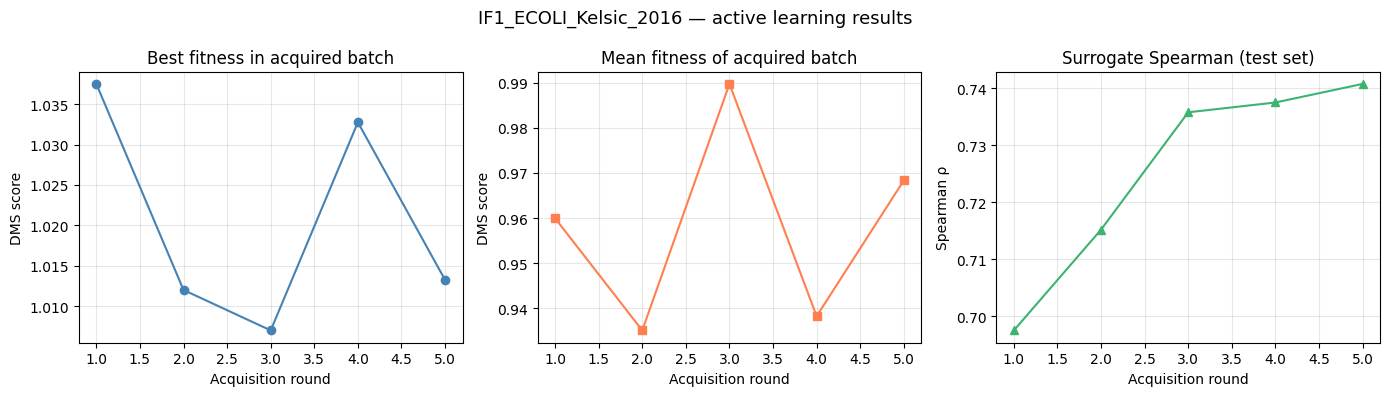

In [13]:
# Filter out the zeroth round (initial training, no acquisitions yet)
metrics_plot = metrics.iloc[1:]
rounds = metrics_plot.index

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(
    rounds,
    metrics_plot["acquired_candidates/round_max"],
    marker="o", color="steelblue",
)
axes[0].set_title("Best fitness in acquired batch")
axes[0].set_xlabel("Acquisition round")
axes[0].set_ylabel("DMS score")
axes[0].grid(alpha=0.3)

axes[1].plot(
    rounds,
    metrics_plot["acquired_candidates/round_mean"],
    marker="s", color="coral",
)
axes[1].set_title("Mean fitness of acquired batch")
axes[1].set_xlabel("Acquisition round")
axes[1].set_ylabel("DMS score")
axes[1].grid(alpha=0.3)

axes[2].plot(
    rounds,
    metrics_plot["surrogate/test_spearman"],
    marker="^", color="mediumseagreen",
)
axes[2].set_title("Surrogate Spearman (test set)")
axes[2].set_xlabel("Acquisition round")
axes[2].set_ylabel("Spearman ρ")
axes[2].grid(alpha=0.3)

fig.suptitle("IF1_ECOLI_Kelsic_2016 — active learning results", fontsize=13)
plt.tight_layout()
plt.show()


In [14]:
# Clean up results directory
if save_path.exists():
    shutil.rmtree(save_path)
    print(f"Removed {save_path}")

Removed results/proteingym


## Conclusion

This tutorial showed how to:

- Load any ProteinGym DMS assay with **no HuggingFace token** — data is fetched
  from the public `OATML-Markslab/ProteinGym_v1` dataset and cached locally.
- Use **ProteinGym's three cross-validation strategies** (modulo, contiguous, random)
  to construct benchmark-aligned train/test splits.
- Run an **offline active learning loop** over the candidate pool using a CNN surrogate
  and a greedy acquisition function.

### Next steps

- Swap `CNNModel` for [`ESM2Model`](https://instadeepai.github.io/alf/api/alf_tools/models/esm2/) to leverage a pre-trained protein language model.
- Try the **multiples** assay type (e.g. `CAPSD_AAV2S_Sinai_2021`) to work with combinatorial libraries.
- Replace `Greedy` with an uncertainty-aware acquisition function such as `UCB` for better exploration.
- Use the modulo or contiguous CV split and compare your surrogate's Spearman correlation against published ProteinGym baselines.